LOADING REAL CALIFORNIA HOUSING DATA

THE FIRST FIVE DATA
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       

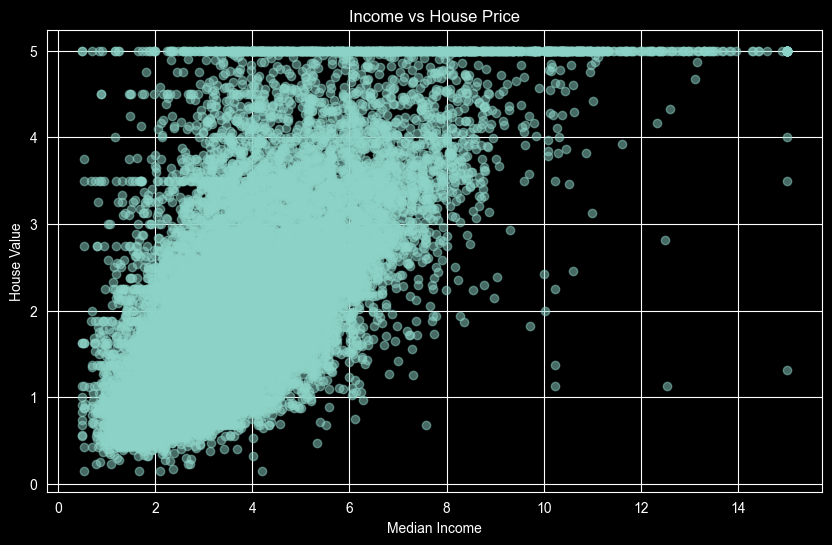

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load a real dataset (using California housing - available in sklearn)
from sklearn.datasets import fetch_california_housing


print("=" * 60)
print("LOADING REAL CALIFORNIA HOUSING DATA")
print("=" * 60)

# Load data
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
print("\nTHE FIRST FIVE DATA")
print(df.head())
print("=" * 60)

print("\nDataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nMedian house value - TARGET")
print(df["MedHouseVal"])
print("=" * 60)

print("\n .feature_names - THE MEASUREMENT NAMES")
print("=" * 50)

print(f"Feature names: {housing.feature_names}")
print(f"Number of features: {len(housing.feature_names)}")

# Let's understand what each feature means
feature_descriptions = {
    'MedInc': 'Median income in block group',
    'HouseAge': 'Median house age in block group',
    'AveRooms': 'Average number of rooms per household',
    'AveBedrms': 'Average number of bedrooms per household',
    'Population': 'Block group population',
    'AveOccup': 'Average number of household members',
    'Latitude': 'Block group latitude',
    'Longitude': 'Block group longitude'
}

print("\n WHAT EACH FEATURE MEANS:")
for feature in housing.feature_names:
    print(f"  • {feature}: {feature_descriptions[feature]}")

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Plot the income vs house price
plt.figure(figsize=(10,6))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Income vs House Price")
plt.show()




## Scatter Plot Insights
- Income vs Price shows that as income goes up the price value goes up too

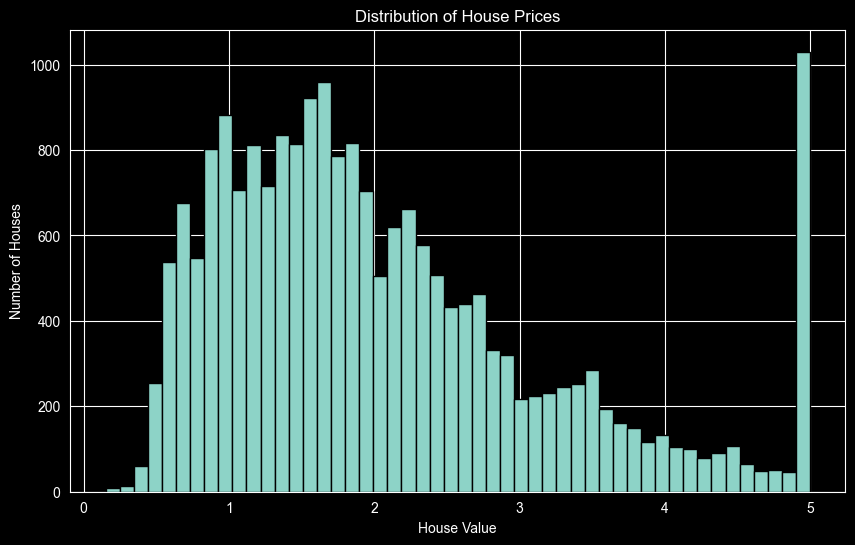

In [6]:
# Plot House Price Distribution
plt.figure(figsize=(10,6))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black')
plt.xlabel("House Value")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

## Plot House Price Distribution
- most houses tend to be cheap from the histogram plot


🏠 REAL EXAMPLE: ANALYZING CALIFORNIA HOUSES


C:\Users\dell\AppData\Local\Temp\ipykernel_8184\3734768723.py:45: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


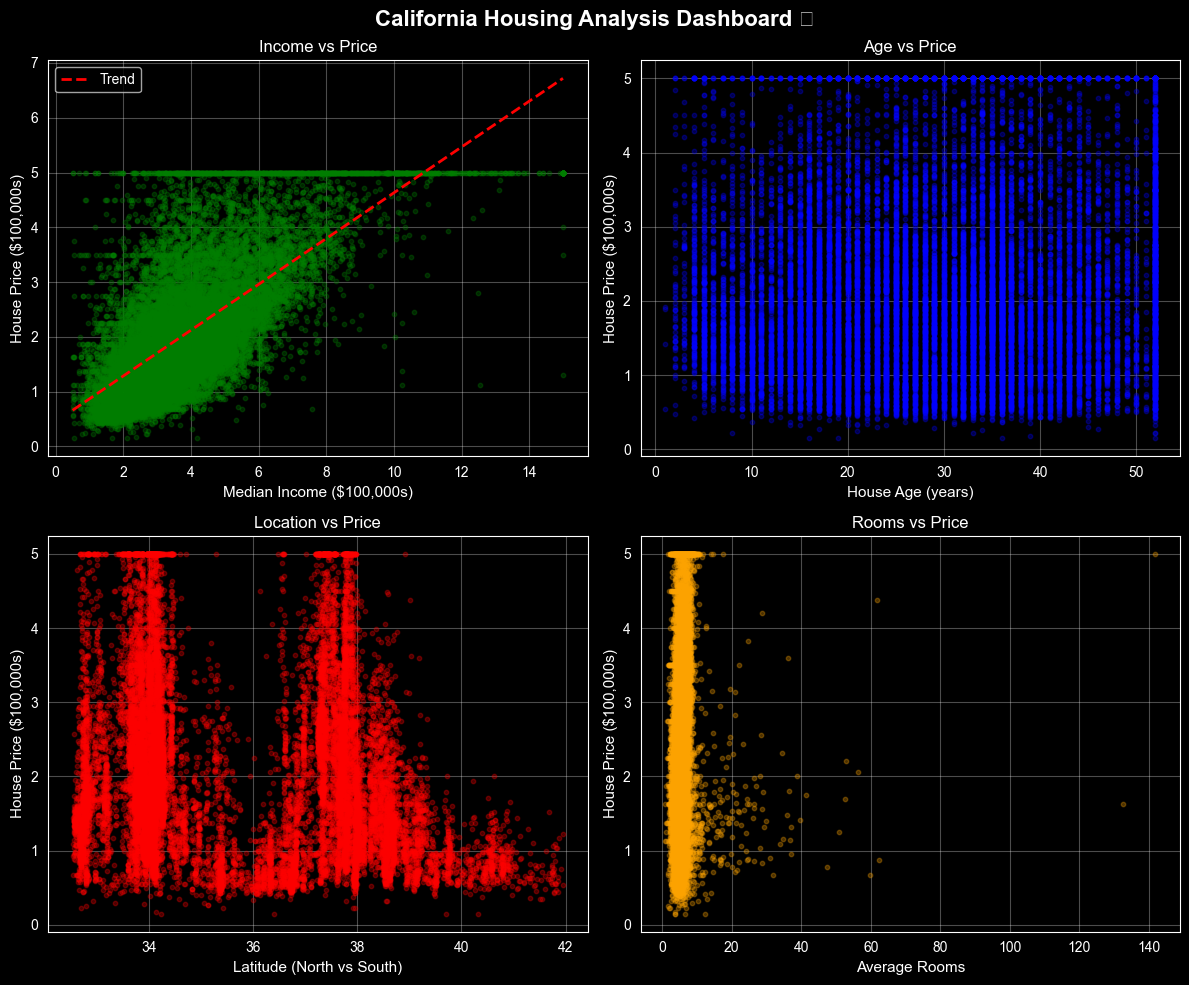

In [7]:

# 2x2 grid showing some subplots of combinations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('California Housing Analysis Dashboard 🏠', fontsize=16, fontweight='bold')

# Box 1: Income vs Price (Most important relationship!)
axes[0, 0].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, s=10, c='green')
axes[0, 0].set_xlabel('Median Income ($100,000s)', fontsize=11)
axes[0, 0].set_ylabel('House Price ($100,000s)', fontsize=11)
axes[0, 0].set_title('Income vs Price', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['MedInc'], df['MedHouseVal'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['MedInc'].sort_values(), p(df['MedInc'].sort_values()),
               'r--', linewidth=2, label='Trend')
axes[0, 0].legend()

# Box 2: House Age vs Price
axes[0, 1].scatter(df['HouseAge'], df['MedHouseVal'], alpha=0.3, s=10, c='blue')
axes[0, 1].set_xlabel('House Age (years)', fontsize=11)
axes[0, 1].set_ylabel('House Price ($100,000s)', fontsize=11)
axes[0, 1].set_title('Age vs Price', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Box 3: Latitude vs Price (North vs South)
axes[1, 0].scatter(df['Latitude'], df['MedHouseVal'], alpha=0.3, s=10, c='red')
axes[1, 0].set_xlabel('Latitude (North vs South)', fontsize=11)
axes[1, 0].set_ylabel('House Price ($100,000s)', fontsize=11)
axes[1, 0].set_title('Location vs Price', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Box 4: Rooms vs Price
axes[1, 1].scatter(df['AveRooms'], df['MedHouseVal'], alpha=0.3, s=10, c='orange')
axes[1, 1].set_xlabel('Average Rooms', fontsize=11)
axes[1, 1].set_ylabel('House Price ($100,000s)', fontsize=11)
axes[1, 1].set_title('Rooms vs Price', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## WHAT DO WE SEE?
- Picture 1 (Positive Correlation): When income goes UP, house price goes UP!"
- Picture 2 (Weak Correlation): When rooms go UP, price goes up a LITTLE"
- Picture 3 (Negative Correlation): When latitude goes UP (more north), price goes DOWN!"